<a href="https://colab.research.google.com/github/li05-afk/Wafer-Defect-Classifier/blob/main/WaferDefectPatternClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Load Dataset
Load a real semiconductor fabrication dataset containing 5,000 wafer records
with 7 process parameters (temperature, pressure, gas flow, etch rate, voltage,
current) and a defect label.

In [10]:
import pandas as pd

df = pd.read_csv('semiconductor_wafer_defect_dataset.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(5000, 9)
['wafer_id', 'temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step', 'defect_label']
   wafer_id  temperature_c  pressure_torr  gas_flow_sccm  etch_rate_nm_min  \
0         1     457.450712     747.287210     113.215053         93.852614   
1         2     447.926035     746.397577     116.945005         94.738753   
2         3     459.715328     706.130705     114.026189         95.514359   
3         4     472.845448     750.097294     121.104180        102.574892   
4         5     446.487699     781.984872     131.971785         89.022262   

   voltage_v  current_ma process_step  defect_label  
0   5.139314   20.341747   Deposition             0  
1   5.113329   20.024511  Lithography             0  
2   4.625392   19.137690   Deposition             0  
3   5.231834   19.994947   Deposition             0  
4   4.403967   20.981683   Deposition             0  


## 2. Exploratory Data Analysis (EDA)
Before building any model, visualise the data to understand how each process
parameter relates to defects.
###Key questions to brain storm:
- Which parameters differ most between normal and defective wafers?
- Which process step has the highest defect rate?

This step drives the feature selection decisions


Defect Distribution:
defect_label
0    4993
1       7
Name: count, dtype: int64

Defect Rate: 0.1%

Process Steps:
process_step
CMP            1029
Oxidation      1027
Etching         997
Lithography     992
Deposition      955
Name: count, dtype: int64


/tmp/ipykernel_3427/2280903696.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='defect_label', y='temperature_c', data=df, ax=axes[0,1], palette=['steelblue','tomato'])
/tmp/ipykernel_3427/2280903696.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='defect_label', y='etch_rate_nm_min', data=df, ax=axes[0,2], palette=['steelblue','tomato'])
/tmp/ipykernel_3427/2280903696.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='defect_label', y='pressure_torr', data=df, ax=axes[1,0], palette=['steelblue','tomato'])


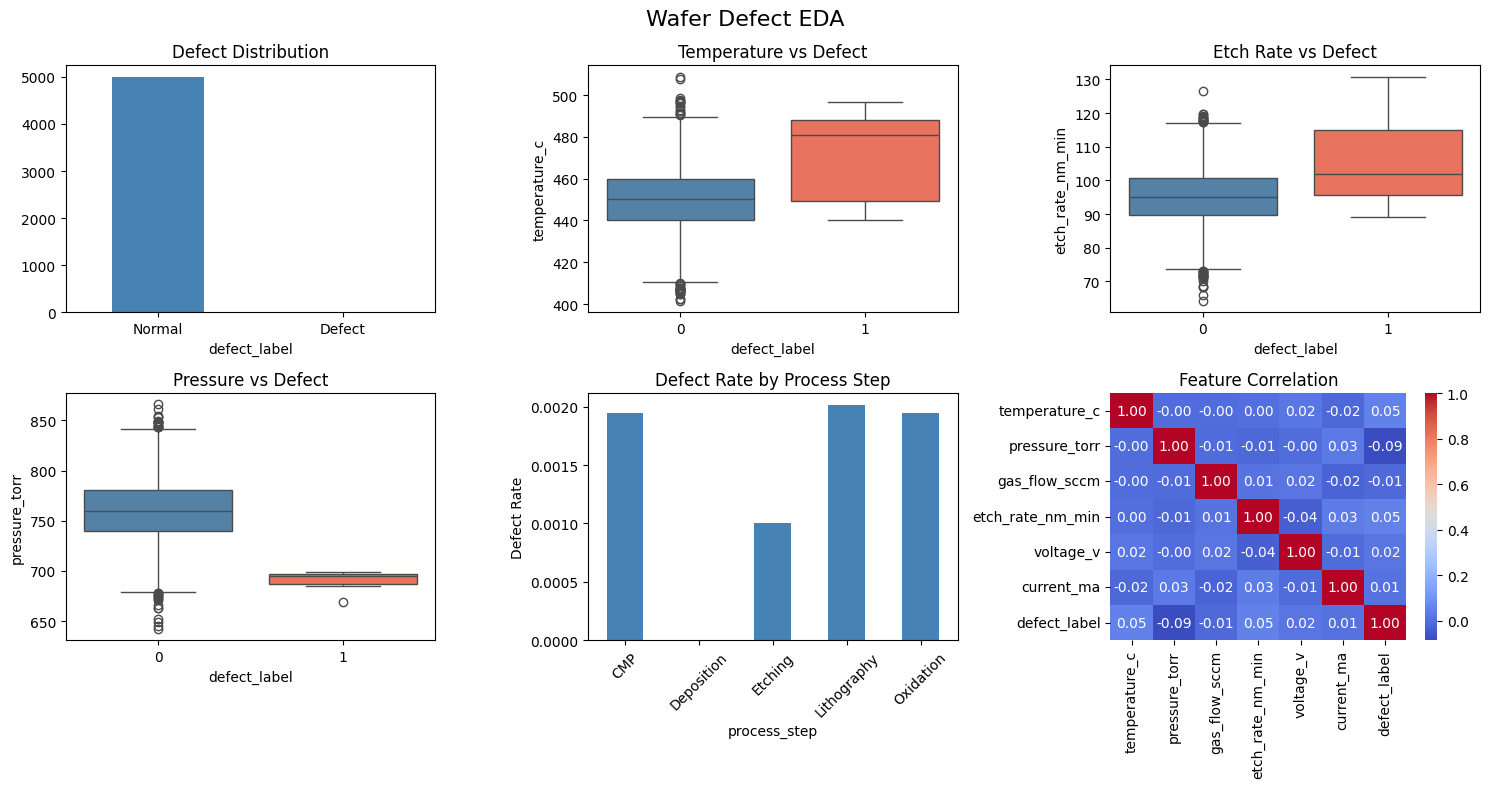

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Quick stats
print("Defect Distribution:")
print(df['defect_label'].value_counts())
print(f"\nDefect Rate: {df['defect_label'].mean()*100:.1f}%")
print("\nProcess Steps:")
print(df['process_step'].value_counts())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Wafer Defect EDA', fontsize=16)

# Defect distribution
df['defect_label'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'])
axes[0,0].set_title('Defect Distribution')
axes[0,0].set_xticklabels(['Normal','Defect'], rotation=0)

# Temperature vs defect
sns.boxplot(x='defect_label', y='temperature_c', data=df, ax=axes[0,1], palette=['steelblue','tomato'])
axes[0,1].set_title('Temperature vs Defect')

# Etch rate vs defect
sns.boxplot(x='defect_label', y='etch_rate_nm_min', data=df, ax=axes[0,2], palette=['steelblue','tomato'])
axes[0,2].set_title('Etch Rate vs Defect')

# Pressure vs defect
sns.boxplot(x='defect_label', y='pressure_torr', data=df, ax=axes[1,0], palette=['steelblue','tomato'])
axes[1,0].set_title('Pressure vs Defect')

# Defect rate by process step
df.groupby('process_step')['defect_label'].mean().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Defect Rate by Process Step')
axes[1,1].set_ylabel('Defect Rate')
axes[1,1].tick_params(axis='x', rotation=45)

# Correlation heatmap
features = ['temperature_c','pressure_torr','gas_flow_sccm','etch_rate_nm_min','voltage_v','current_ma','defect_label']
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', ax=axes[1,2], cmap='coolwarm')
axes[1,2].set_title('Feature Correlation')

plt.tight_layout()
plt.show()

## 3. Handling Class Imbalance with SMOTE
The dataset has a severe imbalance :(

only 7 defective wafers out of 5,000 (0.1%).
If train directly on this, the model will simply predict "Normal" for everything
and still report 99.9% accuracy, making it completely useless for catching real defects

SMOTE (Synthetic Minority Oversampling Technique) fixes this by generating synthetic
samples of the minority class (defective wafers) until both classes are equal.
This forces the model to actually learn what a defective wafer looks like :D

In [12]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Encode process_step (text → number)
le = LabelEncoder()
df['process_step_encoded'] = le.fit_transform(df['process_step'])

# Features and target
features = ['temperature_c','pressure_torr','gas_flow_sccm',
            'etch_rate_nm_min','voltage_v','current_ma','process_step_encoded']
X = df[features]
y = df['defect_label']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {0: 4993, 1: 7}
After SMOTE: {0: 4993, 1: 4993}


## 4. Model Training — Random Forest Classifier
I am using Random Forest Classifier, an ensemble of decision trees because it handles
mixed feature types well, is robust to outliers, and naturally ranks feature
importance. Then split the balanced dataset 80/20 into training and test sets,
train on 7,988 samples, and evaluate on 1,998 unseen samples.
### Feel free to try out other algorithms, think XGBoost is quite good too

## DO NOT USE NAIVE BAYES
Naive Bayes assumes feature independence which is violated since each parameters in the dataset correlated with each other. Naive Bayes cpmpletely ignore these relationships which is a problem :/

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1005
      Defect       1.00      1.00      1.00       993

    accuracy                           1.00      1998
   macro avg       1.00      1.00      1.00      1998
weighted avg       1.00      1.00      1.00      1998



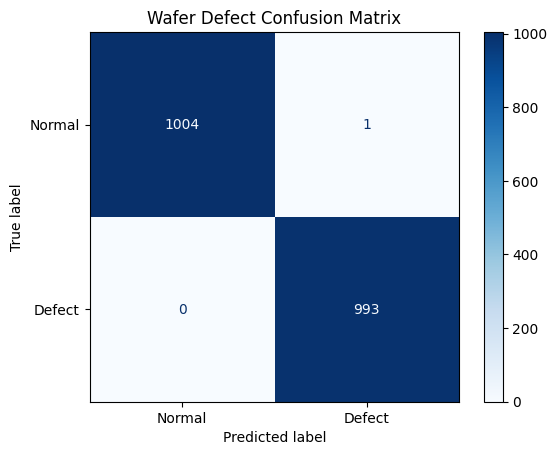

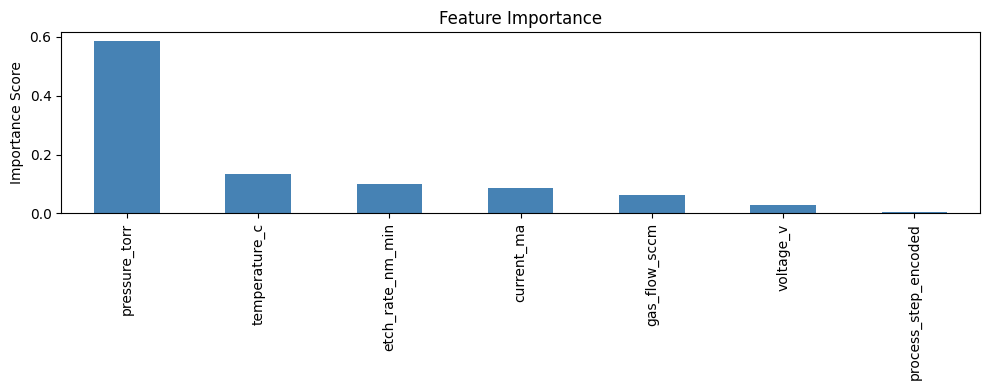

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal','Defect']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal','Defect'])
disp.plot(cmap='Blues')
plt.title('Wafer Defect Confusion Matrix')
plt.show()

# Feature importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(10,4), color='steelblue')
plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

## 5. Model Evaluation
Evaluate using a classification report (precision, recall, F1-score) and a
confusion matrix rather than accuracy alone. This is important because in a
manufacturing context, a false negative (missing a real defect) is far more
costly than a false positive. The feature importance plot tells which process
parameters are the strongest predictors of defects

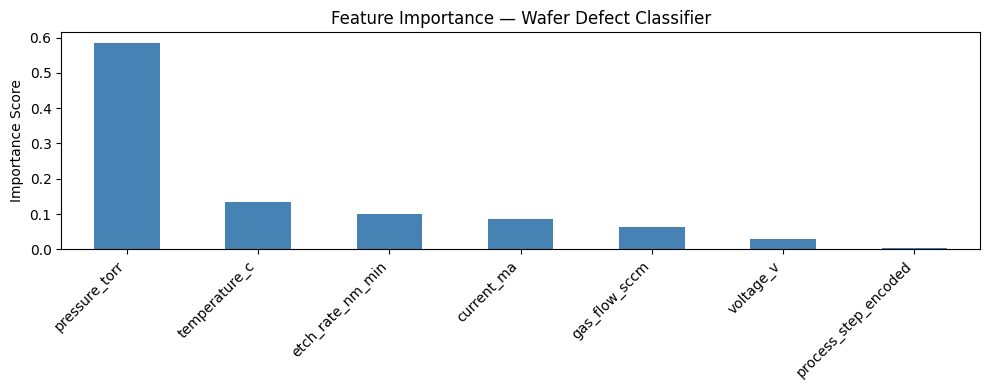

=== Model Summary ===
Training samples : 7988
Test samples     : 1998
Features used    : ['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step_encoded']
Accuracy         : 99.9%
Top feature      : pressure_torr


In [14]:
# Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Wafer Defect Classifier')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Summary
print("=== Model Summary ===")
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features used    : {features}")
print(f"Accuracy         : {rf.score(X_test, y_test)*100:.1f}%")
print(f"Top feature      : {importances.index[0]}")

## 6. Lot Traceability Database Schema
Every wafer lot must be fully traceable from raw process
measurements to final defect outcomes, therefore a relational schema will be designed like so:

- wafer_lots: tracks each wafer ID and its process step
- process_measurements: stores all sensor readings per lot
- defect_results: links actual vs predicted defect labels per lot

I am using SQLite here for portability, but the schema is production-ready for
PostgreSQL which is standard in industrial manufacturing systems

### Using PostgreSQL on Google Colab can get annoying since every time the session resets, you will lose everything ;_;

In [16]:
import sqlite3
import pandas as pd

# Using SQLite since we're on Colab (same SQL concepts as PostgreSQL)
conn = sqlite3.connect('wafer_traceability.db')
cursor = conn.cursor()

# Create tables
cursor.executescript('''
    CREATE TABLE IF NOT EXISTS wafer_lots (
        lot_id INTEGER PRIMARY KEY,
        wafer_id INTEGER,
        process_step TEXT,
        timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
    );

    CREATE TABLE IF NOT EXISTS process_measurements (
        measurement_id INTEGER PRIMARY KEY AUTOINCREMENT,
        lot_id INTEGER,
        temperature_c REAL,
        pressure_torr REAL,
        gas_flow_sccm REAL,
        etch_rate_nm_min REAL,
        voltage_v REAL,
        current_ma REAL,
        FOREIGN KEY (lot_id) REFERENCES wafer_lots(lot_id)
    );

    CREATE TABLE IF NOT EXISTS defect_results (
        result_id INTEGER PRIMARY KEY AUTOINCREMENT,
        lot_id INTEGER,
        defect_label INTEGER,
        predicted_label INTEGER,
        FOREIGN KEY (lot_id) REFERENCES wafer_lots(lot_id)
    );
''')

# Seed with original data
for idx, row in df.iterrows():
    cursor.execute("INSERT OR IGNORE INTO wafer_lots VALUES (?,?,?,CURRENT_TIMESTAMP)",
                   (row['wafer_id'], row['wafer_id'], row['process_step']))
    cursor.execute("INSERT INTO process_measurements VALUES (NULL,?,?,?,?,?,?,?)",
                   (row['wafer_id'], row['temperature_c'], row['pressure_torr'],
                    row['gas_flow_sccm'], row['etch_rate_nm_min'],
                    row['voltage_v'], row['current_ma']))

conn.commit()

# Query to verify
print("Lot Traceability Query")
query = '''
    SELECT w.lot_id, w.process_step,
           ROUND(m.temperature_c, 2) as temp,
           ROUND(m.pressure_torr, 2) as pressure,
           ROUND(m.etch_rate_nm_min, 2) as etch_rate
    FROM wafer_lots w
    JOIN process_measurements m ON w.lot_id = m.lot_id
    LIMIT 10
'''
print(pd.read_sql_query(query, conn))
conn.close()

Lot Traceability Query
   lot_id process_step    temp  pressure  etch_rate
0       1   Deposition  457.45    747.29      93.85
1       2  Lithography  447.93    746.40      94.74
2       3   Deposition  459.72    706.13      95.51
3       4   Deposition  472.85    750.10     102.57
4       5   Deposition  446.49    781.98      89.02
5       6      Etching  446.49    721.77      88.23
6       7  Lithography  473.69    791.45     104.89
7       8   Deposition  461.51    774.63      91.30
8       9    Oxidation  442.96    737.97      84.90
9      10  Lithography  458.14    755.75      91.12
